In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## **Week 1 – Monthly Dataset Aggregation**

In [32]:
sold = pd.read_csv("sold_combined.csv")
listed = pd.read_csv("listed_combined.csv")

/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_7787/3516636363.py:1: DtypeWarning: Columns (0,1,4,9,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("sold_combined.csv")
/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_7787/3516636363.py:2: DtypeWarning: Columns (2,43) have mixed types. Specify dtype option on import or set low_memory=False.
  listed = pd.read_csv("listed_combined.csv")


### **Basic shape and column info**

In [33]:
print("SOLD SHAPE:", sold.shape)
print("LISTED SHAPE:", listed.shape)

print("\nSOLD COLUMNS:")
print(sold.columns.tolist())

print("\nLISTED COLUMNS:")
print(listed.columns.tolist())

SOLD SHAPE: (568183, 84)
LISTED SHAPE: (814004, 84)

SOLD COLUMNS:
['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal',

In [34]:
sold.info()
listed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568183 entries, 0 to 568182
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 498634 non-null  object 
 1   ListAgentAOR                  500146 non-null  object 
 2   Flooring                      334069 non-null  object 
 3   ViewYN                        511151 non-null  object 
 4   WaterfrontYN                  313 non-null     object 
 5   BasementYN                    9393 non-null    object 
 6   PoolPrivateYN                 496545 non-null  object 
 7   OriginalListPrice             566540 non-null  float64
 8   ListingKey                    568183 non-null  int64  
 9   ListAgentEmail                547714 non-null  object 
 10  CloseDate                     568183 non-null  object 
 11  ClosePrice                    568176 non-null  float64
 12  ListAgentFirstName            564855 non-nul

### **Check property types**

In [35]:
print("Sold property types:")
print(sold["PropertyType"].value_counts(dropna=False))

print("\nListed property types:")
print(listed["PropertyType"].value_counts(dropna=False))

Sold property types:
PropertyType
Residential            381849
ResidentialLease       130090
Land                    18564
ManufacturedInPark      15433
ResidentialIncome       15295
CommercialSale           3568
CommercialLease          2992
BusinessOpportunity       392
Name: count, dtype: int64

Listed property types:
PropertyType
Residential            514651
ResidentialLease       170875
Land                    53851
ResidentialIncome       29954
ManufacturedInPark      23451
CommercialSale          11189
CommercialLease          7401
BusinessOpportunity      2632
Name: count, dtype: int64


In [36]:
# Filter to Residential ONLY
sold_res = sold[sold["PropertyType"] == "Residential"].copy()
listed_res = listed[listed["PropertyType"] == "Residential"].copy()

print("Sold before:", len(sold))
print("Sold after Residential filter:", len(sold_res))

print("Listed before:", len(listed))
print("Listed after Residential filter:", len(listed_res))

Sold before: 568183
Sold after Residential filter: 381849
Listed before: 814004
Listed after Residential filter: 514651


In [37]:
sold_res.to_csv("sold_residential.csv", index=False)
listed_res.to_csv("listed_residential.csv", index=False)

print("\nFiles saved successfully!")


Files saved successfully!


## **Weeks 2–3 – Dataset Structuring and Validation**

Load Residential datasets
Inspect shape and columns
Check data types
Missing value summary
Flag columns above 90% null
Numeric summaries
Histograms and boxplots
Answer key EDA questions
Save validated datasets

### **1. Load Residential datasets**

In [38]:
sold_res = pd.read_csv("sold_residential.csv", low_memory=False)
listed_res = pd.read_csv("listed_residential.csv", low_memory=False)

This loads the Residential-only datasets from Week 1. Using low_memory=False helps avoid mixed-type warnings when pandas reads large CSVs.

### **2. Basic shape check**

In [45]:
print("SOLD SHAPE:", sold_res.shape)
print("LISTED SHAPE:", listed_res.shape)
sold.head()

SOLD SHAPE: (381849, 84)
LISTED SHAPE: (514651, 84)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,HighDesert,HighDesert,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,...,92394,NaN,52320.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
2,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,...,93240,NaN,217364.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
3,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,...,92308,NaN,217800.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,...,93544,0.0,108883.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [46]:
listed.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,NaN,NaN,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,NaN,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road


In [48]:
# View columns
print(sold.columns.tolist())
print(listed.columns.tolist())

# # This helps identify:
#     + key market variables
# `   + possible metadata columns
#     + columns that may matter later for feature engineering and Tableau

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [50]:
print(sold.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568183 entries, 0 to 568182
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 498634 non-null  object 
 1   ListAgentAOR                  500146 non-null  object 
 2   Flooring                      334069 non-null  object 
 3   ViewYN                        511151 non-null  object 
 4   WaterfrontYN                  313 non-null     object 
 5   BasementYN                    9393 non-null    object 
 6   PoolPrivateYN                 496545 non-null  object 
 7   OriginalListPrice             566540 non-null  float64
 8   ListingKey                    568183 non-null  int64  
 9   ListAgentEmail                547714 non-null  object 
 10  CloseDate                     568183 non-null  object 
 11  ClosePrice                    568176 non-null  float64
 12  ListAgentFirstName            564855 non-nul

In [51]:
print(listed.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814004 entries, 0 to 814003
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             810807 non-null  float64
 1   ListingKey                    814004 non-null  int64  
 2   ListAgentEmail                780379 non-null  object 
 3   CloseDate                     256261 non-null  object 
 4   ClosePrice                    234994 non-null  float64
 5   ListAgentFirstName            809227 non-null  object 
 6   ListAgentLastName             813929 non-null  object 
 7   Latitude                      702703 non-null  float64
 8   Longitude                     703391 non-null  float64
 9   UnparsedAddress               811989 non-null  object 
 10  PropertyType                  814004 non-null  object 
 11  LivingArea                    712394 non-null  float64
 12  ListPrice                     811936 non-nul

Checking:

    which columns are numeric
    which are objects/text
    which columns have lots of missing values
    whether date columns are still strings

This matters because some columns that should be numeric may still be stored as text.

In [52]:
# Confirm Residential-only
print(sold["PropertyType"].value_counts(dropna=False))
print(listed["PropertyType"].value_counts(dropna=False))

PropertyType
Residential            381849
ResidentialLease       130090
Land                    18564
ManufacturedInPark      15433
ResidentialIncome       15295
CommercialSale           3568
CommercialLease          2992
BusinessOpportunity       392
Name: count, dtype: int64
PropertyType
Residential            514651
ResidentialLease       170875
Land                    53851
ResidentialIncome       29954
ManufacturedInPark      23451
CommercialSale          11189
CommercialLease          7401
BusinessOpportunity      2632
Name: count, dtype: int64


In [53]:
# Missing value summary for sold
sold_nulls = pd.DataFrame({
    "null_count": sold.isnull().sum(),
    "null_pct": sold.isnull().mean() * 100
}).sort_values("null_pct", ascending=False)

sold_nulls.head(20)

,null_count,null_pct
AboveGradeFinishedArea,568183,100.000000
FireplacesTotal,568183,100.000000
ElementarySchoolDistrict,568183,100.000000
CoveredSpaces,568183,100.000000
MiddleOrJuniorSchoolDistrict,568183,100.000000
WaterfrontYN,567870,99.944912
TaxYear,567831,99.938048
BusinessType,566611,99.723329
TaxAnnualAmount,565746,99.571089
BelowGradeFinishedArea,565698,99.562641


In [54]:
# Missing value summary for listed
listed_nulls = pd.DataFrame({
    "null_count": listed.isnull().sum(),
    "null_pct": listed.isnull().mean() * 100
}).sort_values("null_pct", ascending=False)

listed_nulls.head(20)

,null_count,null_pct
CoveredSpaces,814004,100.000000
FireplacesTotal,814004,100.000000
ElementarySchoolDistrict,814004,100.000000
MiddleOrJuniorSchoolDistrict,814004,100.000000
AboveGradeFinishedArea,814004,100.000000
TaxYear,813173,99.897912
BelowGradeFinishedArea,810762,99.601722
BusinessType,808250,99.293124
TaxAnnualAmount,808247,99.292755
CoBuyerAgentFirstName,794159,97.562051


In [56]:
# Flag columns above 90% missing
print("Sold columns > 90% null:")
display(sold_nulls[sold_nulls["null_pct"] > 90])

print("Listed columns > 90% null:")
display(listed_nulls[listed_nulls["null_pct"] > 90])

Sold columns > 90% null:


,null_count,null_pct
AboveGradeFinishedArea,568183,100.000000
FireplacesTotal,568183,100.000000
ElementarySchoolDistrict,568183,100.000000
CoveredSpaces,568183,100.000000
MiddleOrJuniorSchoolDistrict,568183,100.000000
WaterfrontYN,567870,99.944912
TaxYear,567831,99.938048
BusinessType,566611,99.723329
TaxAnnualAmount,565746,99.571089
BelowGradeFinishedArea,565698,99.562641


Listed columns > 90% null:


,null_count,null_pct
CoveredSpaces,814004,100.000000
FireplacesTotal,814004,100.000000
ElementarySchoolDistrict,814004,100.000000
MiddleOrJuniorSchoolDistrict,814004,100.000000
AboveGradeFinishedArea,814004,100.000000
TaxYear,813173,99.897912
BelowGradeFinishedArea,810762,99.601722
BusinessType,808250,99.293124
TaxAnnualAmount,808247,99.292755
CoBuyerAgentFirstName,794159,97.562051


In [57]:
# Required numeric summaries
summary_cols = ["ClosePrice", "LivingArea", "DaysOnMarket"]

numeric_summary = sold[summary_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

numeric_summary["median"] = sold[summary_cols].median()

numeric_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,median
ClosePrice,568176.0,874880.380533,5.302353e+06,0.0,1750.0,2695.0,54000.0,630000.0,1070000.0,2500000.0,4995000.0,989500000.0,630000.0
LivingArea,528027.0,3565.278874,1.251281e+06,0.0,480.0,735.0,1183.0,1580.0,2150.0,3538.0,5467.0,909090909.0,1580.0
DaysOnMarket,568183.0,43.095888,6.969935e+01,-288.0,0.0,2.0,9.0,22.0,54.0,146.0,289.0,12430.0,22.0


In [58]:
# Optional broader numeric review
extra_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]
existing_cols = [col for col in extra_cols if col in sold.columns]
display(sold[existing_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,568176.0,874880.380533,5.302353e+06,0.0,1750.0,2695.0000,54000.0000,630000.0000,1.070000e+06,2.500000e+06,4.995000e+06,9.895000e+08
ListPrice,567308.0,839893.105432,1.273505e+06,0.0,1795.0,2700.0000,64937.5000,629990.0000,1.050000e+06,2.498000e+06,4.998800e+06,1.375000e+08
OriginalListPrice,566540.0,907710.130654,5.850916e+06,0.0,1800.0,2750.0000,65000.0000,640000.0000,1.089000e+06,2.549000e+06,5.295000e+06,1.390000e+09
LivingArea,528027.0,3565.278874,1.251281e+06,0.0,480.0,735.0000,1183.0000,1580.0000,2.150000e+03,3.538000e+03,5.467000e+03,9.090909e+08
LotSizeAcres,514130.0,793.919546,5.165767e+05,0.0,0.0,0.0275,0.1194,0.1676,2.977750e-01,3.559190e+00,1.598380e+01,3.702600e+08
BedroomsTotal,530279.0,3.080854,1.401027e+00,0.0,1.0,1.0000,2.0000,3.0000,4.000000e+00,5.000000e+00,6.000000e+00,1.230000e+02
BathroomsTotalInteger,541784.0,2.445687,1.417672e+00,0.0,0.0,1.0000,2.0000,2.0000,3.000000e+00,4.000000e+00,6.000000e+00,1.750000e+02
DaysOnMarket,568183.0,43.095888,6.969935e+01,-288.0,0.0,2.0000,9.0000,22.0000,5.400000e+01,1.460000e+02,2.890000e+02,1.243000e+04
YearBuilt,544267.0,1978.066238,2.708347e+01,1776.0,1911.0,1927.0000,1960.0000,1979.0000,1.999000e+03,2.022000e+03,2.025000e+03,2.026000e+03


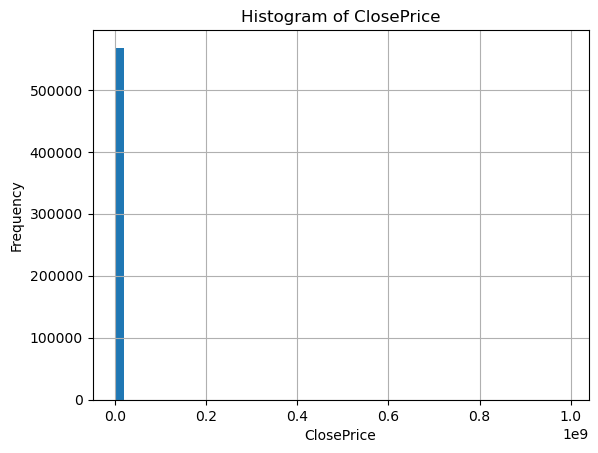

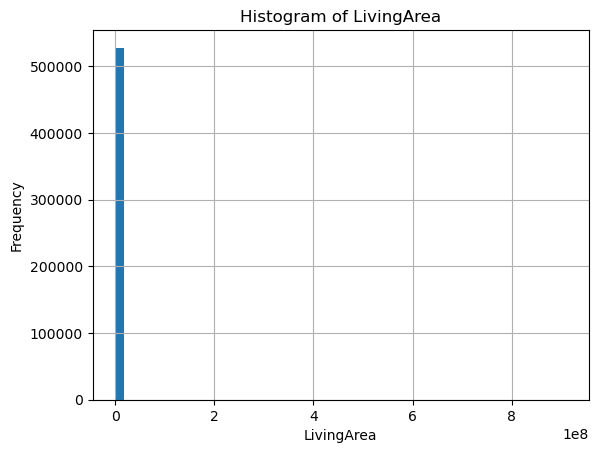

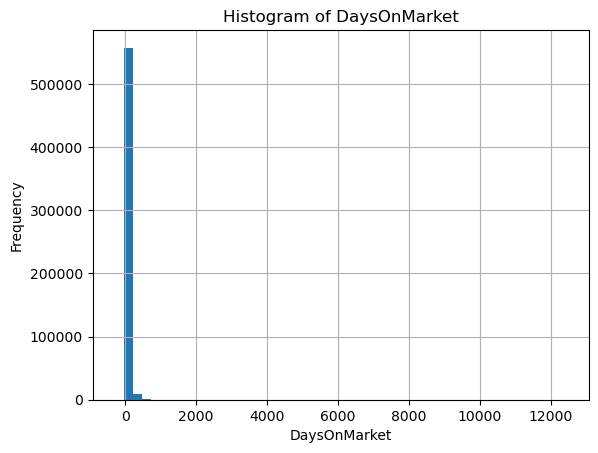

In [66]:
# Histograms
for col in ["ClosePrice", "LivingArea", "DaysOnMarket"]:
    if col in sold.columns:
        sold[col].dropna().hist(bins=50)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

The distributions of ClosePrice, LivingArea, and DaysOnMarket are all heavily right-skewed, with a large concentration of values at lower ranges and extreme outliers extending the upper tails. These outliers significantly distort the distributions and will need to be addressed in later data cleaning and outlier detection steps.

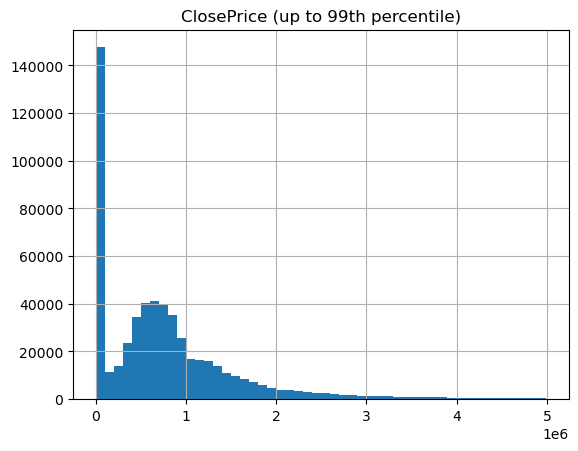

In [69]:
upper = sold["ClosePrice"].quantile(0.99)

sold[sold["ClosePrice"] <= upper]["ClosePrice"].hist(bins=50)
plt.title("ClosePrice (up to 99th percentile)")
plt.show()

After removing the top 1% of values, the distribution of ClosePrice becomes more interpretable, showing a concentration of homes between approximately $300,000 and $1,000,000. A small spike near zero suggests the presence of invalid or missing values, which will need to be addressed during data cleaning.

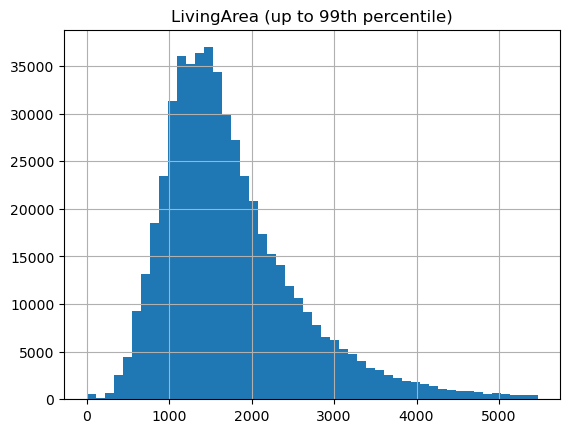

In [70]:
upper = sold["LivingArea"].quantile(0.99)

sold[sold["LivingArea"] <= upper]["LivingArea"].hist(bins=50)
plt.title("LivingArea (up to 99th percentile)")
plt.show()

After removing the top 1% of values, the distribution of LivingArea appears right-skewed, with most homes concentrated between approximately 1,000 and 2,000 square feet. Larger properties form a long right tail, which is expected in housing data.

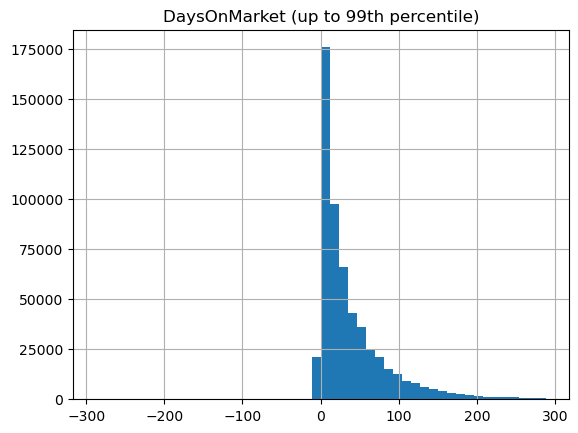

In [71]:
upper = sold["DaysOnMarket"].quantile(0.99)

sold[sold["DaysOnMarket"] <= upper]["DaysOnMarket"].hist(bins=50)
plt.title("DaysOnMarket (up to 99th percentile)")
plt.show()

The distribution of DaysOnMarket is right-skewed, with most properties selling within a relatively short time frame. However, the presence of negative values indicates data quality issues, likely due to inconsistencies in date calculations or recording errors. These records will need to be addressed during data cleaning.

In [75]:
sold[sold["DaysOnMarket"] < 0].shape


(59, 85)

In [74]:
sold[sold["DaysOnMarket"] < 0].head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,ClosePrice_log
31,CoastalMendocino,CoastalMendocino,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,...,NaN,74487.6,NaN,CRMLS,CRMLS_CRF,NaN,NaN,NaN,NaN,14.483340
826,VenturaCoastal,VenturaCoastal,Vinyl,False,NaN,NaN,True,2975.0,1055498337,cindyisalways@gmail.com,...,0.0,3920.0,NaN,CRMLS,CRMLS_CRF,NaN,NaN,NaN,NaN,7.998335
1676,PasadenaFoothills,PasadenaFoothills,Laminate,False,NaN,NaN,False,4000.0,1054112664,arbi.derian@compass.com,...,0.0,6098.0,NaN,CRMLS,CRMLS_CRF,NaN,NaN,NaN,NaN,8.294300
3838,PasadenaFoothills,PasadenaFoothills,Vinyl,False,NaN,NaN,False,3950.0,1052391149,amyponce888@gmail.com,...,0.0,5661.0,NaN,CRMLS,CRMLS_CRF,NaN,NaN,NaN,NaN,8.281724
9426,CaliforniaDesert,CaliforniaDesert,Carpet,True,NaN,NaN,False,120000.0,1047183932,martyjelmberg@gmail.com,...,NaN,800.0,NaN,CRMLS,CRMLS_CDAR,NaN,NaN,NaN,NaN,11.695255


A small number of records (59 observations) contain negative DaysOnMarket values, which are not logically valid. These likely result from inconsistencies in date calculations or data entry errors. These records will be addressed during the data cleaning phase.

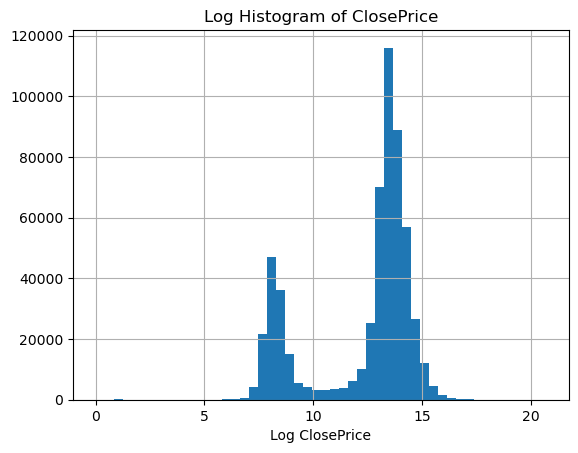

In [67]:
sold["ClosePrice_log"] = np.log1p(sold["ClosePrice"])

sold["ClosePrice_log"].hist(bins=50)
plt.title("Log Histogram of ClosePrice")
plt.xlabel("Log ClosePrice")
plt.show()

In [76]:
sold_nulls.head(10)

,null_count,null_pct
AboveGradeFinishedArea,568183,100.000000
FireplacesTotal,568183,100.000000
ElementarySchoolDistrict,568183,100.000000
CoveredSpaces,568183,100.000000
MiddleOrJuniorSchoolDistrict,568183,100.000000
WaterfrontYN,567870,99.944912
TaxYear,567831,99.938048
BusinessType,566611,99.723329
TaxAnnualAmount,565746,99.571089
BelowGradeFinishedArea,565698,99.562641


Several columns exhibit extremely high missingness, with some variables containing 100% null values and others exceeding 99% missingness. These columns provide little to no analytical value and will be removed in later data cleaning steps to improve dataset quality and efficiency.

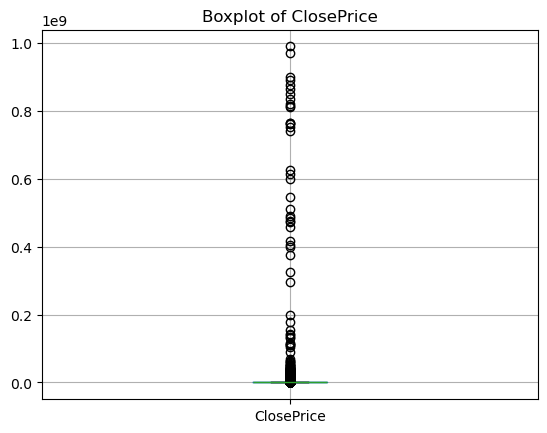

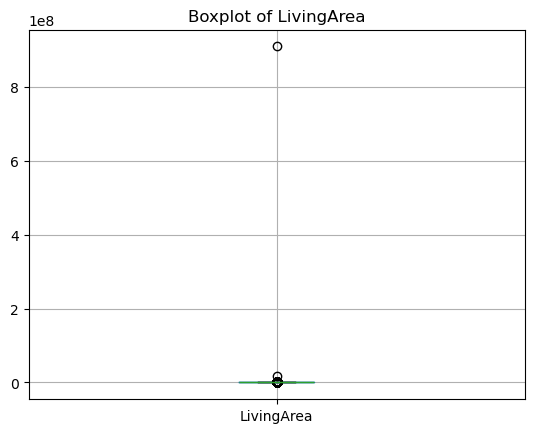

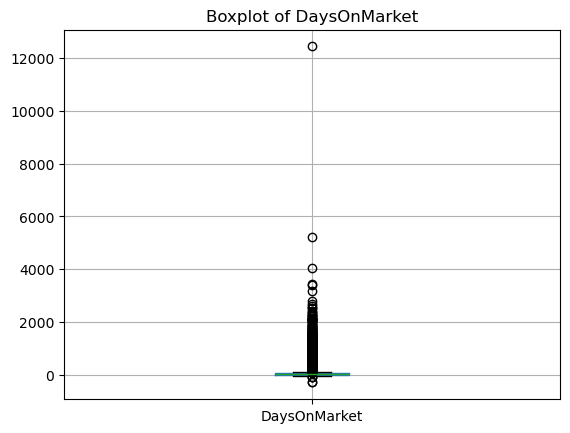

In [68]:
# Boxplots
for col in ["ClosePrice", "LivingArea", "DaysOnMarket"]:
    if col in sold.columns:
        sold.boxplot(column=col)
        plt.title(f"Boxplot of {col}")
        plt.show()

Boxplots of key numerical variables confirm the presence of significant outliers in ClosePrice, LivingArea, and DaysOnMarket. These variables exhibit strong right-skewed distributions, with a small number of extreme values extending far beyond the interquartile range. These outliers may represent either valid extreme cases (e.g., luxury properties) or data quality issues and will be addressed in subsequent cleaning and outlier detection steps.

In [77]:
sold[["ClosePrice","LivingArea","DaysOnMarket"]].describe()

,ClosePrice,LivingArea,DaysOnMarket
count,5.681760e+05,5.280270e+05,568183.000000
mean,8.748804e+05,3.565279e+03,43.095888
std,5.302353e+06,1.251281e+06,69.699353
min,0.000000e+00,0.000000e+00,-288.000000
25%,5.400000e+04,1.183000e+03,9.000000
50%,6.300000e+05,1.580000e+03,22.000000
75%,1.070000e+06,2.150000e+03,54.000000
max,9.895000e+08,9.090909e+08,12430.000000


In [78]:
sold.to_csv("sold_validated.csv", index=False)
listed.to_csv("listed_validated.csv", index=False)

In [ ]:
# Ignore data files
*.csv

# Ignore raw data folder
raw/

# Python cache
__pycache__/
.ipynb_checkpoints/

# system files
.DS_Store